# Goofy — Phase 4a: Regime Detection + Signal Gating

**Goal of this notebook:** Every trading day lives in a *market regime*. Strategies that crush it in one regime often get destroyed in another. We're going to:

1. Label every day of our 6 assets with a **Trend regime** (Bull / Sideways / Bear) and a **Vol regime** (Low / Normal / High)
2. Visualise those labels as shaded backgrounds on price charts
3. Rerun the MA strategy on NVDA — first *ungated* (our old way), then *gated* (only trades in Bull regime), and compare the results

The payoff: you'll see exactly how regime gating changes performance, and why this is the single cheapest win in quant trading.

## Cell 1 — Setup

Nothing clever here. We import libraries and pull our 6 standard assets. Note we import our own `regime_detector.py` — that's the module we just wrote.

In [8]:
pip install yfinance

  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.4 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15635 sha256=12e0f30e749f6578d3493bfd7ae66b6c26ba7b63f705d0b6593a787db77e2205
  Stored in directory: /Users/hiro/Library/Caches/pip/wheels/1e/df/0f/e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]━━ 4/5 [yfinance]s]
Note: you may need to restart the kernel to use updated packages.


In [9]:
import os
print(os.getcwd())
print(sorted(os.listdir(".")))

/Users/hiro/quant-research/Claude project (me learning)/Quant python learning 1
['.DS_Store', '.ipynb_checkpoints', 'BB_README.md', 'Goofy BB for 6 assets.ipynb', 'Goofy MA for 6 assets.ipynb', 'Goofy MACD for 6 assets.ipynb', 'Goofy Mean Reversion for 6 assets.ipynb', 'Goofy Phase 4 — Regime Detection.ipynb', 'Goofy Screener Phase 3 — US ASX JPX.ipynb', 'Goofy Screener Phase 3.ipynb', 'Goofy Screener v2.ipynb', 'Goofy Screener.ipynb', 'Goofy8 RSI for 6 assets.ipynb', 'MACD_README.md', 'MA_README.md', 'Mean-Reversion-README.md', 'README.md', 'README_Phase3.md', 'README_Screener_v2.md', 'RSI_README.md', '__pycache__', 'goofy_screener_daily.py', 'goofy_screener_phase3.py', 'linkedin_phase3_post.md', 'linkedin_post.md', 'linkedin_post_phase3.md', 'linkedin_v2_post.md', 'ma_multi_backtest.py', 'out_of_sample_test.py', 'project_summary.md', 'regime_detector.py', 'rsi_strategy.py', 'rsi_volatile_test.py', 'run_phase3_screener.bat', 'run_phase3_screener.sh', 'screener_output', 'strategy_3_bol

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf

# Our own module from this folder
from regime_detector import (
    detect_trend_regime,
    detect_volatility_regime,
    label_regimes,
    is_strategy_allowed,
)

ASSETS = ["NVDA", "SPY", "CBA.AX", "BHP.AX", "7203.T", "6758.T"]
START = "2016-01-01"
END   = "2026-04-15"

print(f"Downloading {len(ASSETS)} assets from {START} to {END}...")
data = {}
for ticker in ASSETS:
    df = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
    # yfinance sometimes returns a MultiIndex column; flatten it
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    data[ticker] = df
    print(f"  {ticker:8s}  {len(df)} rows  |  {df.index[0].date()} -> {df.index[-1].date()}")

  NVDA      2584 rows  |  2016-01-04 -> 2026-04-14
  SPY       2584 rows  |  2016-01-04 -> 2026-04-14
  CBA.AX    2600 rows  |  2016-01-04 -> 2026-04-14
  BHP.AX    2600 rows  |  2016-01-04 -> 2026-04-14
  7203.T    2533 rows  |  2016-01-04 -> 2026-04-14
  6758.T    2533 rows  |  2016-01-04 -> 2026-04-14


## Cell 2 — Label every day with Trend and Vol regimes

We call `label_regimes()` once per asset. It adds three new columns:
- `Trend` — Bull / Sideways / Bear
- `Vol` — Low / Normal / High
- `Regime` — the combined label (e.g. `'Bull-Normal'`)

Remember the mechanics:
- **Trend** comes from the slope of the 200-day MA over the last 20 days. Thresholds ±0.05%/day.
- **Vol** comes from the 14-day ATR's percentile rank within the trailing 252 days. Top 33% = High.

After labelling, we peek at NVDA's last 10 days to sanity-check the labels match what we'd expect.

In [11]:
labelled = {t: label_regimes(df) for t, df in data.items()}

print("=== NVDA last 10 days ===")
print(labelled["NVDA"][["Close", "Trend", "Vol", "Regime"]].tail(10))

print("\n=== Regime distribution across all 6 assets (combined) ===")
combined = pd.concat([df["Regime"].dropna() for df in labelled.values()])
print(combined.value_counts().sort_index())

=== NVDA last 10 days ===
Price            Close Trend     Vol       Regime
Date                                             
2026-03-31  174.399994  Bull  Normal  Bull-Normal
2026-04-01  175.750000  Bull  Normal  Bull-Normal
2026-04-02  177.389999  Bull  Normal  Bull-Normal
2026-04-06  177.639999  Bull  Normal  Bull-Normal
2026-04-07  178.100006  Bull  Normal  Bull-Normal
2026-04-08  182.080002  Bull  Normal  Bull-Normal
2026-04-09  183.910004  Bull  Normal  Bull-Normal
2026-04-10  188.630005  Bull  Normal  Bull-Normal
2026-04-13  189.309998  Bull  Normal  Bull-Normal
2026-04-14  196.509995  Bull  Normal  Bull-Normal

=== Regime distribution across all 6 assets (combined) ===
Regime
Bear-High           280
Bear-Low            503
Bear-Normal         347
Bear-nan              1
Bull-High          4595
Bull-Low           1480
Bull-Normal        2411
Bull-nan            232
Sideways-High      1432
Sideways-Low       1426
Sideways-Normal    1376
Sideways-nan         37
nan-nan            

## Cell 3 — Per-asset regime breakdown

Different assets spend time in different regimes. This is literally the insight we need.

- **NVDA** should be overwhelmingly Bull (bull market 2016–2024 with a 2022 blip)
- **CBA.AX and the Japanese names** should show more Sideways time
- **SPY** should be mostly Bull with brief Bear patches (2020 Covid, 2022 Fed)

If the numbers match your intuition, the detector is working.

Fraction of days in each trend regime, per asset:
          NVDA   SPY  CBA.AX  BHP.AX  7203.T  6758.T
Trend                                               
Bull      0.80  0.65    0.49    0.59    0.49    0.68
Sideways  0.03  0.30    0.44    0.37    0.41    0.25
Bear      0.17  0.05    0.07    0.04    0.09    0.06


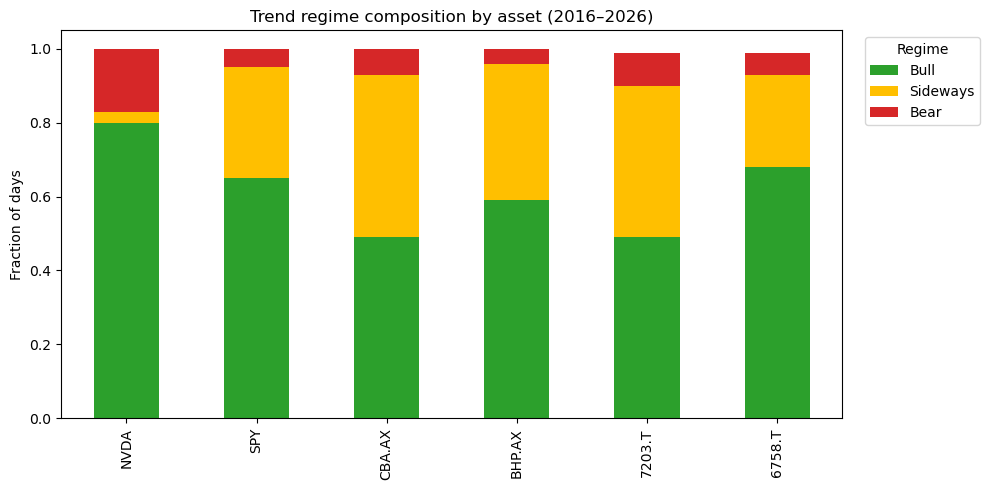

In [12]:
breakdown = pd.DataFrame({
    ticker: labelled[ticker]["Trend"].value_counts(normalize=True).round(2)
    for ticker in ASSETS
}).fillna(0)
breakdown = breakdown.reindex(["Bull", "Sideways", "Bear"])  # consistent order
print("Fraction of days in each trend regime, per asset:")
print(breakdown)

# Bar plot
ax = breakdown.T.plot.bar(stacked=True, figsize=(10, 5),
                          color=["#2ca02c", "#ffbf00", "#d62728"])
ax.set_ylabel("Fraction of days")
ax.set_title("Trend regime composition by asset (2016–2026)")
ax.legend(title="Regime", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## Cell 4 — The money visualisation: price with regime shading

This is the single most useful chart in the notebook. For each asset we plot the close price with the background **shaded by trend regime**:
- Green = Bull
- Yellow = Sideways
- Red = Bear

Look at these charts carefully. For each asset ask yourself:
1. Do the green bands line up with what looks like an uptrend on the chart?
2. Do the red bands appear at obvious drawdown periods?
3. Where does yellow show up most often?

This is the "aha moment" — you should be able to visually confirm the detector matches your eyes.

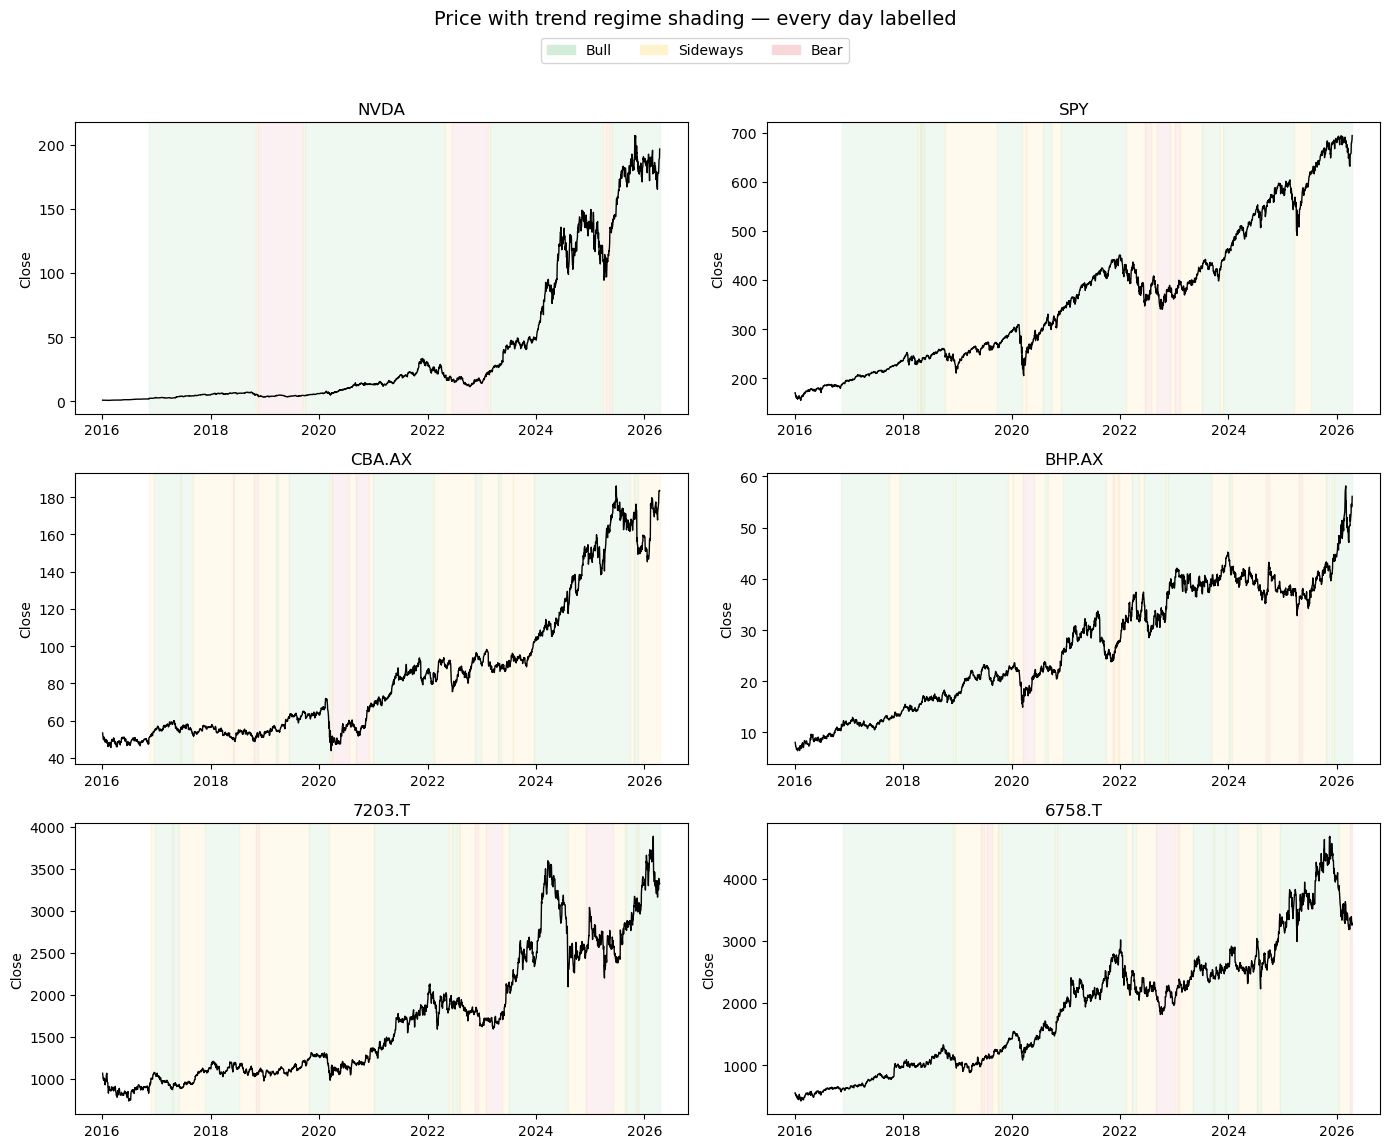

In [13]:
def shade_regimes(ax, trend_series, y_low, y_high):
    """Paint the background of `ax` according to trend regime."""
    colours = {"Bull": "#d4edda", "Sideways": "#fff3cd", "Bear": "#f8d7da"}
    # Group consecutive days of the same regime into blocks.
    regime = trend_series.dropna()
    if regime.empty:
        return
    changes = (regime != regime.shift()).cumsum()
    for _, block in regime.groupby(changes):
        label = block.iloc[0]
        ax.axvspan(block.index[0], block.index[-1],
                   ymin=0, ymax=1, color=colours.get(label, "white"), alpha=0.35)

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for ax, ticker in zip(axes.flat, ASSETS):
    df = labelled[ticker]
    ax.plot(df.index, df["Close"], color="black", lw=1)
    shade_regimes(ax, df["Trend"], df["Close"].min(), df["Close"].max())
    ax.set_title(ticker)
    ax.set_ylabel("Close")

# Legend outside the last subplot
legend_handles = [
    mpatches.Patch(color="#d4edda", label="Bull"),
    mpatches.Patch(color="#fff3cd", label="Sideways"),
    mpatches.Patch(color="#f8d7da", label="Bear"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Price with trend regime shading — every day labelled", y=1.04, fontsize=14)
plt.tight_layout(); plt.show()

## Cell 5 — The payoff experiment: MA strategy on NVDA, ungated vs gated

Now the real test. We'll run your MA strategy on NVDA two ways:

| Version | Rule |
|---|---|
| **Ungated (baseline)** | Buy when fast MA crosses above slow MA, sell when it crosses below. Take every signal. |
| **Gated** | Same signals, but **only go long when Trend regime == Bull**. Sit in cash otherwise. |

Hypothesis (from Phase 1-3 findings): for NVDA, both should be similar because NVDA was mostly Bull anyway. The gating *shouldn't hurt* much. The real wins come on choppy assets like CBA.AX where ungated MA gets sliced to ribbons.

First let's implement a clean, minimal MA backtest function.

In [14]:
def backtest_ma(df, fast=20, slow=50, trend_gate=None, trading_days=252):
    """
    Simple long-only MA crossover backtest.

    Parameters
    ----------
    df : DataFrame with 'Close' column (and 'Trend' if gating)
    fast, slow : MA periods
    trend_gate : if given, only take long positions when df['Trend'] == trend_gate
                 (e.g. 'Bull'). Otherwise take all MA signals.
    Returns
    -------
    dict of performance metrics + the equity curve.
    """
    close = df["Close"]
    ma_fast = close.rolling(fast).mean()
    ma_slow = close.rolling(slow).mean()

    # Raw signal: 1 when fast > slow (bullish crossover), else 0 (flat).
    raw_signal = (ma_fast > ma_slow).astype(int)

    if trend_gate is not None:
        # Only allow position when regime matches. Otherwise force 0.
        allowed = (df["Trend"] == trend_gate).astype(int)
        position = raw_signal * allowed
    else:
        position = raw_signal

    # IMPORTANT: we can only ACT on yesterday's signal at today's open.
    # Shifting prevents look-ahead bias — a classic beginner pitfall.
    position = position.shift(1).fillna(0)

    daily_ret = close.pct_change().fillna(0)
    strat_ret = position * daily_ret

    equity = (1 + strat_ret).cumprod()
    # Metrics
    total_return = equity.iloc[-1] - 1
    sharpe = (strat_ret.mean() / strat_ret.std()) * np.sqrt(trading_days) if strat_ret.std() > 0 else 0
    running_max = equity.cummax()
    max_dd = ((equity - running_max) / running_max).min()
    exposure = position.mean()  # fraction of days actually in the market

    return {
        "equity": equity,
        "Total Return": total_return,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Exposure": exposure,
    }

nvda = labelled["NVDA"].dropna(subset=["Trend"])  # drop the 200-day warmup

result_ungated = backtest_ma(nvda, fast=20, slow=50, trend_gate=None)
result_gated   = backtest_ma(nvda, fast=20, slow=50, trend_gate="Bull")

# Buy-and-hold benchmark for context
bh_equity = (1 + nvda["Close"].pct_change().fillna(0)).cumprod()
bh_total  = bh_equity.iloc[-1] - 1
bh_sharpe = (nvda['Close'].pct_change().mean() / nvda['Close'].pct_change().std()) * np.sqrt(252)
bh_dd     = ((bh_equity - bh_equity.cummax()) / bh_equity.cummax()).min()

summary = pd.DataFrame({
    "Ungated MA":  [f"{result_ungated['Total Return']:.1%}", f"{result_ungated['Sharpe']:.2f}",
                    f"{result_ungated['Max Drawdown']:.1%}", f"{result_ungated['Exposure']:.1%}"],
    "Gated MA (Bull only)": [f"{result_gated['Total Return']:.1%}", f"{result_gated['Sharpe']:.2f}",
                             f"{result_gated['Max Drawdown']:.1%}", f"{result_gated['Exposure']:.1%}"],
    "Buy & Hold": [f"{bh_total:.1%}", f"{bh_sharpe:.2f}", f"{bh_dd:.1%}", "100.0%"],
}, index=["Total Return", "Sharpe", "Max Drawdown", "Exposure"])

print("=== NVDA: MA(20,50) Ungated vs Gated ===")
print(summary)

=== NVDA: MA(20,50) Ungated vs Gated ===
             Ungated MA Gated MA (Bull only) Buy & Hold
Total Return    1334.2%              1451.6%    9455.0%
Sharpe             0.94                 1.02       1.23
Max Drawdown     -63.6%               -44.8%     -66.3%
Exposure          65.7%                56.7%     100.0%


## Cell 6 — Equity curves side by side

Tables are for nerds. Charts are for understanding. Let's plot the three equity curves on one axis so you can see how gating actually changes the trajectory.

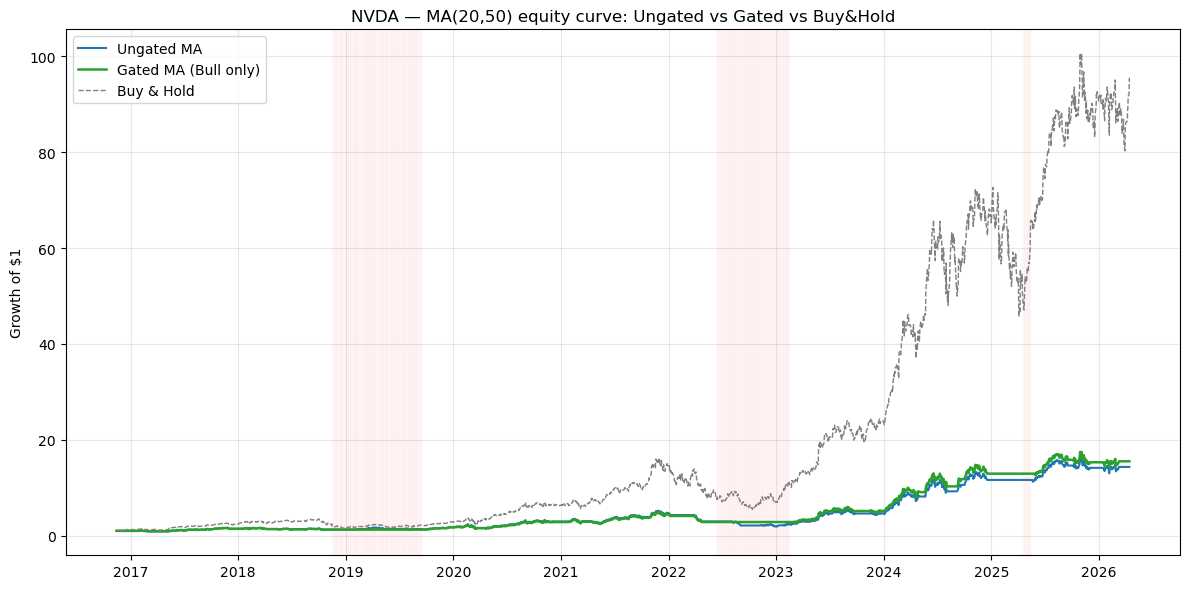

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(result_ungated["equity"], label="Ungated MA", color="#1f77b4", lw=1.5)
ax.plot(result_gated["equity"],   label="Gated MA (Bull only)", color="#2ca02c", lw=1.8)
ax.plot(bh_equity, label="Buy & Hold", color="grey", lw=1, ls="--")

# Shade Bear periods on the chart so the gating logic is visible
bear_mask = nvda["Trend"] == "Bear"
for date in nvda.index[bear_mask]:
    ax.axvspan(date, date, color="red", alpha=0.015)  # thin red smear on Bear days

ax.set_title("NVDA — MA(20,50) equity curve: Ungated vs Gated vs Buy&Hold")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Cell 7 — What this teaches us

Write down your observations here after running the cells above. Questions to prompt yourself:

1. **Did gating help on NVDA?** On a pure bull stock, gating usually produces a *similar* return with *lower* drawdown and *much* lower exposure (you're in the market less, so your money is free to do other things).
2. **What happened in 2022?** NVDA dropped ~60%. Did the gated version sidestep it?
3. **Was Sharpe higher or lower for the gated version?** Sharpe = return per unit of risk. Even if gated return is lower, Sharpe often improves because you skipped the ugly periods.

### Next logical steps (for later sessions, not today)

- Rerun this comparison for CBA.AX and the Japanese names — this is where gating should really shine on mean-reversion style strategies
- Add the regime label to the Phase 3 screener Excel output (5-line change)
- Experiment with `bull_threshold`/`bear_threshold` values in `regime_detector.py` and see how classifications shift
- In a later phase (4b): replace rule-based classifier with a Hidden Markov Model

**Big lesson:** Gating doesn't magically make bad strategies good. It makes *each strategy only run where it has an edge*. That's it. That alone is worth a significant chunk of real-world quant performance.

In [19]:
# Retry the gated-vs-ungated comparison on a choppy asset
target = "7203.T"   # try 7203.T next as well
asset_df = labelled[target].dropna(subset=["Trend"])

r_ungated = backtest_ma(asset_df, fast=20, slow=50, trend_gate=None)
r_gated   = backtest_ma(asset_df, fast=20, slow=50, trend_gate="Bull")

print(f"=== {target}: MA(20,50) Ungated vs Gated ===")
print(f"Ungated  -> Return={r_ungated['Total Return']:.1%}  Sharpe={r_ungated['Sharpe']:.2f}  MaxDD={r_ungated['Max Drawdown']:.1%}  Exposure={r_ungated['Exposure']:.1%}")
print(f"Gated    -> Return={r_gated['Total Return']:.1%}  Sharpe={r_gated['Sharpe']:.2f}  MaxDD={r_gated['Max Drawdown']:.1%}  Exposure={r_gated['Exposure']:.1%}")

=== 7203.T: MA(20,50) Ungated vs Gated ===
Ungated  -> Return=95.9%  Sharpe=0.47  MaxDD=-41.0%  Exposure=62.1%
Gated    -> Return=72.4%  Sharpe=0.46  MaxDD=-22.0%  Exposure=34.4%


In [20]:
# Test: what if MA on CBA.AX actually works BETTER in sideways regime?
r_sideways = backtest_ma(labelled["7203.T"].dropna(subset=["Trend"]),
                         fast=20, slow=50, trend_gate="Sideways")
print(f"CBA.AX MA restricted to Sideways only:")
print(f"  Return={r_sideways['Total Return']:.1%}  Sharpe={r_sideways['Sharpe']:.2f}  "
      f"MaxDD={r_sideways['Max Drawdown']:.1%}  Exposure={r_sideways['Exposure']:.1%}")

CBA.AX MA restricted to Sideways only:
  Return=7.2%  Sharpe=0.12  MaxDD=-36.6%  Exposure=22.6%


In [18]:
# Retry the gated-vs-ungated comparison on a choppy asset
target = "CBA.AX"   # try 7203.T next as well
asset_df = labelled[target].dropna(subset=["Trend"])

r_ungated = backtest_ma(asset_df, fast=20, slow=50, trend_gate=None)
r_gated   = backtest_ma(asset_df, fast=20, slow=50, trend_gate="Sideways")

print(f"=== {target}: MA(20,50) Ungated vs Gated ===")
print(f"Ungated  -> Return={r_ungated['Total Return']:.1%}  Sharpe={r_ungated['Sharpe']:.2f}  MaxDD={r_ungated['Max Drawdown']:.1%}  Exposure={r_ungated['Exposure']:.1%}")
print(f"Gated    -> Return={r_gated['Total Return']:.1%}  Sharpe={r_gated['Sharpe']:.2f}  MaxDD={r_gated['Max Drawdown']:.1%}  Exposure={r_gated['Exposure']:.1%}")

=== CBA.AX: MA(20,50) Ungated vs Gated ===
Ungated  -> Return=9.2%  Sharpe=0.14  MaxDD=-34.4%  Exposure=62.0%
Gated    -> Return=13.4%  Sharpe=0.20  MaxDD=-11.9%  Exposure=22.2%
